In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import numpy as np
import requests
import json
import io
import concurrent.futures
from tqdm import tqdm
from torchvision import transforms
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
class AttLayer(nn.Module):
    def __init__(self, hidden_size, seq_len):
        super(AttLayer, self).__init__()
        self.W = nn.Linear(hidden_size, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(seq_len, 1))
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        e = torch.tanh(self.W(x) + self.bias)
        e = e.squeeze(-1)
        alpha = self.softmax(e)
        alpha = alpha.unsqueeze(-1)
        output = torch.sum(alpha * x, dim=1)
        return output


class BabaModel(nn.Module):
    def __init__(self, input_dim=5, k_size=3, seq_len=60, dropout=0.3):
        super(BabaModel, self).__init__()
        
        self.conv1 = nn.Conv1d(input_dim, 128, kernel_size=k_size, padding=1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(128, 128, kernel_size=k_size, padding=1)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        
        self.conv3 = nn.Conv1d(128, 128, kernel_size=k_size, padding=1)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout)
        
        # LSTM Block
        # Input: 128 features, Output: 200 hidden
        self.lstm = nn.LSTM(128, 200, batch_first=True)
        self.dropout4 = nn.Dropout(dropout) # No ReLU here, as requested
        
        self.lstm2 = nn.LSTM(200, 200, batch_first=True)
        self.dropout5 = nn.Dropout(dropout)
        
        self.lstm3 = nn.LSTM(200, 200, batch_first=True)
        self.dropout6 = nn.Dropout(dropout)
        
        # Attention & Output
        self.att = AttLayer(200, seq_len=seq_len)
        self.fc = nn.Linear(200, 7) 
        # REMOVED: self.sigmoid (Linear output for Regression)

    def forward(self, x):
        # x shape: [Batch, Seq_Len, Features] -> [Batch, 60, 5]
        
        # Permute for CNN: [Batch, Features, Seq_Len]
        x = x.permute(0, 2, 1) 
        
        # CNN Layers
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        
        # Permute for LSTM: [Batch, Seq_Len, Channels] -> [Batch, 60, 128]
        x = x.permute(0, 2, 1)
        
        # LSTM Layers
        x, _ = self.lstm(x)
        x = self.dropout4(x)
        
        x, _ = self.lstm2(x)
        x = self.dropout5(x)
        
        x, _ = self.lstm3(x)
        x = self.dropout6(x)
        
        # Attention & Output
        x = self.att(x)
        x = self.fc(x)
        # No Sigmoid here
        
        return x

In [3]:
import random
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

In [4]:
def train_one_epoch(model,train_loader,epoch,optimizer):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for inputs, targets , *_ in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = MSE(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.6f}")
    return avg_train_loss

def validate(model,val_loader):

    model.eval()
    val_running_loss = 0.0
    val_loop = tqdm(val_loader)

    with torch.no_grad():
        for inputs, targets , *_ in val_loop:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = MSE(outputs, targets)

            val_running_loss += loss.item()
            val_loop.set_postfix(loss=loss.item())

    avg_val_loss = val_running_loss / len(val_loader)

    print(f"Val Loss: {avg_val_loss:.6f}")
    return avg_val_loss

In [5]:
df=pd.read_csv("C.csv")
df.head()

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

df[['Open', 'High', 'Low', 'Adj Close', 'Volume']] = feature_scaler.fit_transform(
    df[['Open', 'High', 'Low', 'Adj Close', 'Volume']]
)

df['Close'] = target_scaler.fit_transform(df[['Close']])

def create_sequences(df, seq_length, forecast_length):
    sequences = []
    for i in range(len(df) - seq_length - forecast_length):
        seq = df.iloc[i:i + seq_length].copy()
        target = df['Close'].iloc[i + seq_length:i + seq_length + forecast_length].values
        sequences.append((seq, target))
    return sequences

SEQ_LENGTH = 60
FORECAST_LENGTH = 7
sequences = create_sequences(df, SEQ_LENGTH, FORECAST_LENGTH)

X, y = zip(*sequences)
X = np.array([seq[['Open', 'High', 'Low', 'Adj Close', 'Volume']].values for seq in X])
y = np.array(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1,random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader_basic = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_basic = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [6]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=BabaModel(k_size=3,seq_len=60).to(device)
MSE=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

schedular=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.1,patience=5)

patience = 10
patience_counter = 0
best_val_loss = float('inf')
num_epochs = 1000
history_base = []
for epoch in range(num_epochs):
    avg_train_loss = train_one_epoch(model=model,train_loader=train_loader_basic,epoch=epoch,optimizer=optimizer)
    avg_val_loss = validate(model=model,val_loader=val_loader_basic)

    schedular.step(avg_val_loss)
    history_base.append([avg_train_loss,avg_val_loss])
    if avg_val_loss < best_val_loss:
        torch.save(model.state_dict(), "Baba_model.pth")

        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"EarlyStopping counter: {patience_counter} out of {patience}")
        if patience_counter >= patience:
            print("Early stopping triggered. Training halted.")
            break



Epoch 1/1000 [Train]: 100%|██████████| 70/70 [00:01<00:00, 40.85it/s, loss=0.00285] 


Epoch 1: Train Loss: 0.014661


100%|██████████| 8/8 [00:00<00:00, 137.27it/s, loss=0.00393]


Val Loss: 0.002698


Epoch 2/1000 [Train]: 100%|██████████| 70/70 [00:00<00:00, 77.76it/s, loss=0.00129] 


...

Val Loss: 0.000212
EarlyStopping counter: 9 out of 10


Epoch 47/1000 [Train]: 100%|██████████| 70/70 [00:00<00:00, 70.86it/s, loss=0.000447]


Epoch 47: Train Loss: 0.000233


100%|██████████| 8/8 [00:00<00:00, 148.09it/s, loss=0.000321]

Val Loss: 0.000222
EarlyStopping counter: 10 out of 10
Early stopping triggered. Training halted.


In [7]:
def load_model(checkpoint_path, device=None ,model = None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint, strict=True)
    model.to(device)
    model.eval() 
    
    return model


In [8]:
model_base = BabaModel(k_size=3, seq_len=60)
model_base = load_model("Baba_model.pth",device,model_base)

In [9]:
model_bi = BabaModel(k_size=3, seq_len=5)

model_bi.lstm = nn.LSTM(128, 200, batch_first=True, bidirectional=True)

model_bi.lstm2 = nn.LSTM(400, 200, batch_first=True, bidirectional=True)

model_bi.lstm3 = nn.LSTM(400, 200, batch_first=True, bidirectional=True)

model_bi.att = AttLayer(hidden_size=400, seq_len=60)

model_bi.fc = nn.Linear(400, 7)


In [10]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
MSE=nn.MSELoss()
optimizer=optim.Adam(model_bi.parameters(),lr=0.001)
model_bi = model_bi.to(device)
schedular=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.1,patience=5)

patience = 10
patience_counter = 0
best_val_loss = float('inf')
num_epochs = 100
history_bi=[]
for epoch in range(num_epochs):
    avg_train_loss = train_one_epoch(model=model_bi,train_loader=train_loader_basic,epoch=epoch,optimizer=optimizer)
    avg_val_loss = validate(model=model_bi,val_loader=val_loader_basic)

    schedular.step(avg_val_loss)
    history_bi.append([avg_train_loss,avg_val_loss])

    if avg_val_loss < best_val_loss:
        torch.save(model_bi.state_dict(), "Baba_model_bi.pth")

        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"EarlyStopping counter: {patience_counter} out of {patience}")
        if patience_counter >= patience:
            print("Early stopping triggered. Training halted.")
            break



Epoch 1/100 [Train]: 100%|██████████| 70/70 [00:01<00:00, 44.06it/s, loss=0.00177] 


Epoch 1: Train Loss: 0.012372


100%|██████████| 8/8 [00:00<00:00, 120.51it/s, loss=0.00119]


Val Loss: 0.001518


Epoch 2/100 [Train]: 100%|██████████| 70/70 [00:01<00:00, 39.90it/s, loss=0.000436]


...

Val Loss: 0.000222
EarlyStopping counter: 9 out of 10


Epoch 56/100 [Train]: 100%|██████████| 70/70 [00:01<00:00, 44.57it/s, loss=0.000109]


Epoch 56: Train Loss: 0.000201


100%|██████████| 8/8 [00:00<00:00, 113.60it/s, loss=0.00026]

Val Loss: 0.000230
EarlyStopping counter: 10 out of 10
Early stopping triggered. Training halted.


In [11]:
model_bi = BabaModel(k_size=3, seq_len=60)

model_bi.lstm = nn.LSTM(128, 200, batch_first=True, bidirectional=True)

model_bi.lstm2 = nn.LSTM(400, 200, batch_first=True, bidirectional=True)

model_bi.lstm3 = nn.LSTM(400, 200, batch_first=True, bidirectional=True)

model_bi.att = AttLayer(hidden_size=400, seq_len=60)

model_bi.fc = nn.Linear(400, 7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bi = load_model("Baba_model_bi.pth",device,model_bi)

In [28]:
def plot_training_curves(history):
    # Just line graph for history val train loss
    train_losses = []
    test_losses= []
    for record in history:
        train_losses.append(record[0])
        test_losses.append(record[1])

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, accuracy_score

def evaluate_model(model, val_loader, device):
    model.eval()
    
    all_price_preds = []
    all_price_targets = []

    with torch.no_grad():
        for inputs, targets_price, *_ in val_loader:
            inputs = inputs.to(device)
            targets_price = targets_price.to(device)
            
            # Forward pass
            pred_price = model(inputs)
            
            # Move to CPU and flatten
            # Flattening ensures we have a 1D array of all time steps sequentially
            all_price_preds.extend(pred_price.cpu().numpy().flatten())
            all_price_targets.extend(targets_price.cpu().numpy().flatten())

    # Convert lists to numpy arrays
    price_preds = np.array(all_price_preds)
    price_targets = np.array(all_price_targets)

    # --- 1. Regression Metrics ---
    print("\n" + "="*40)
    print("   PRICE PREDICTION METRICS (Regression)")
    print("="*40)
    
    mae = mean_absolute_error(price_targets, price_preds)
    mse = mean_squared_error(price_targets, price_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(price_targets, price_preds)

    print(f"Mean Absolute Error (MAE): {mae:.6f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
    print(f"R-Squared (R2): {r2:.6f}")

    # --- 2. Derived Trend Metrics (Classification) ---
    # We compare t vs t-1.
    # Actual Trend: Did the actual price go up or down compared to the previous actual price?
    # Predicted Trend: Did the predicted price go up or down compared to the previous ACTUAL price?
    # (Using previous actual price is standard for 'one-step-ahead' directional accuracy)
    
    if len(price_targets) > 1:
        # Calculate differences (Current - Previous)
        actual_diff = price_targets[1:] - price_targets[:-1]
        pred_diff = price_preds[1:] - price_targets[:-1]
        
        # Binarize: 1 for Up (diff > 0), 0 for Down/Flat (diff <= 0)
        true_trend = (actual_diff > 0).astype(int)
        pred_trend = (pred_diff > 0).astype(int)
        
        trend_f1 = f1_score(true_trend, pred_trend)
        trend_acc = accuracy_score(true_trend, pred_trend)
        
        print("\n" + "="*40)
        print("   DERIVED TREND METRICS (Classification)")
        print("="*40)
        print(f"Directional F1 Score: {trend_f1:.4f}")
        print(f"Directional Accuracy: {trend_acc:.2%}")
    
    # --- 3. Visualization ---
    plt.figure(figsize=(12, 6))
    plt.plot(price_targets, label='Actual Price', color='black', alpha=0.7)
    plt.plot(price_preds, label='Predicted Price', color='#00CCFF', alpha=0.7)
    plt.title('Model Evaluation: Predicted vs Actual Prices')
    plt.xlabel('Time Steps (Flattened)')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return mae, r2, trend_f1

In [13]:
model_base = load_model("Baba_model.pth",device,model_base)

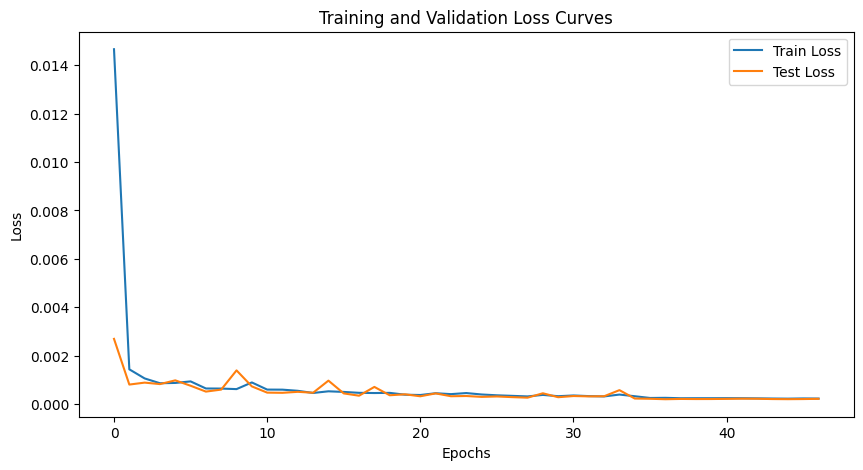

In [29]:
plot_training_curves(history_base)


   PRICE PREDICTION METRICS (Regression)
Mean Absolute Error (MAE): 0.008087
Root Mean Squared Error (RMSE): 0.014196
R-Squared (R2): 0.997888

   DERIVED TREND METRICS (Classification)
Directional F1 Score: 0.5910
Directional Accuracy: 57.02%


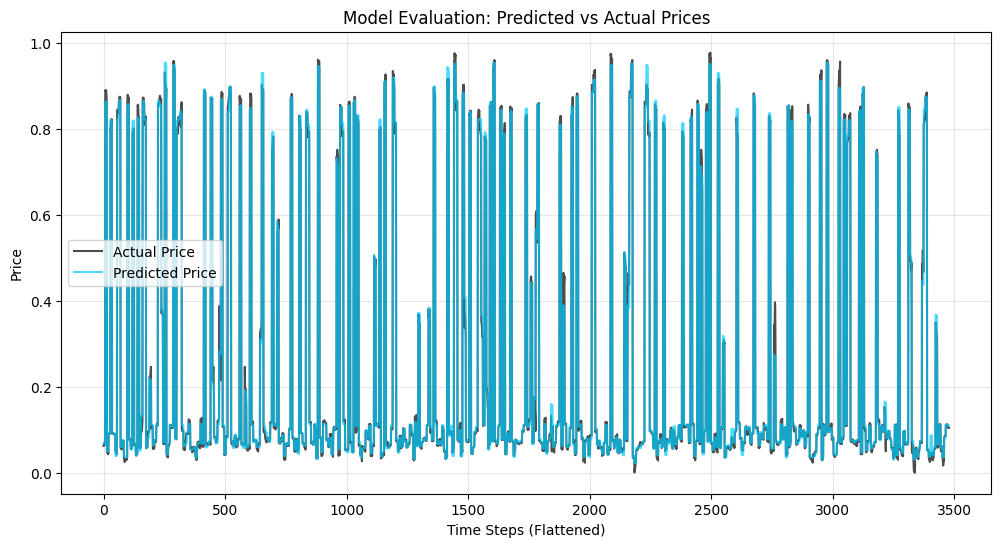

(0.008086884394288063, 0.9978880286216736, 0.5909712722298222)

In [14]:
evaluate_model(model=model_base, val_loader=val_loader_basic , device= device)

In [15]:
model_bi = load_model(model=model_bi, checkpoint_path="Baba_model_bi.pth" , device= device)


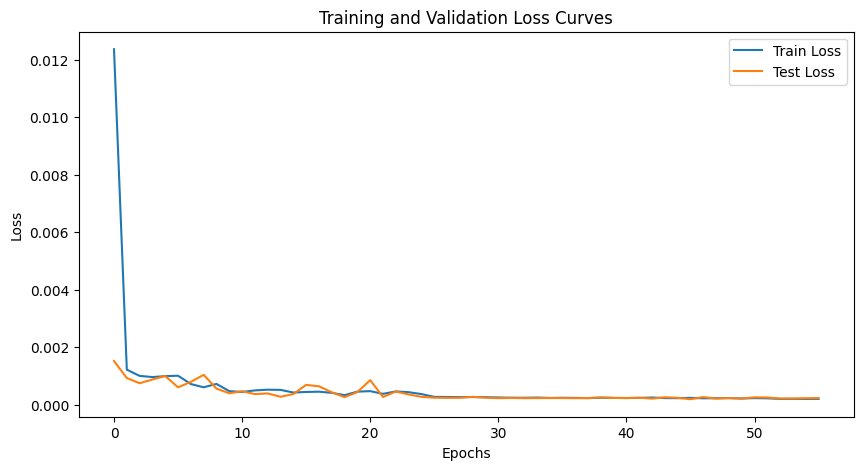

In [30]:
plot_training_curves(history_bi)



   PRICE PREDICTION METRICS (Regression)
Mean Absolute Error (MAE): 0.008251
Root Mean Squared Error (RMSE): 0.013631
R-Squared (R2): 0.998053

   DERIVED TREND METRICS (Classification)
Directional F1 Score: 0.5236
Directional Accuracy: 57.36%


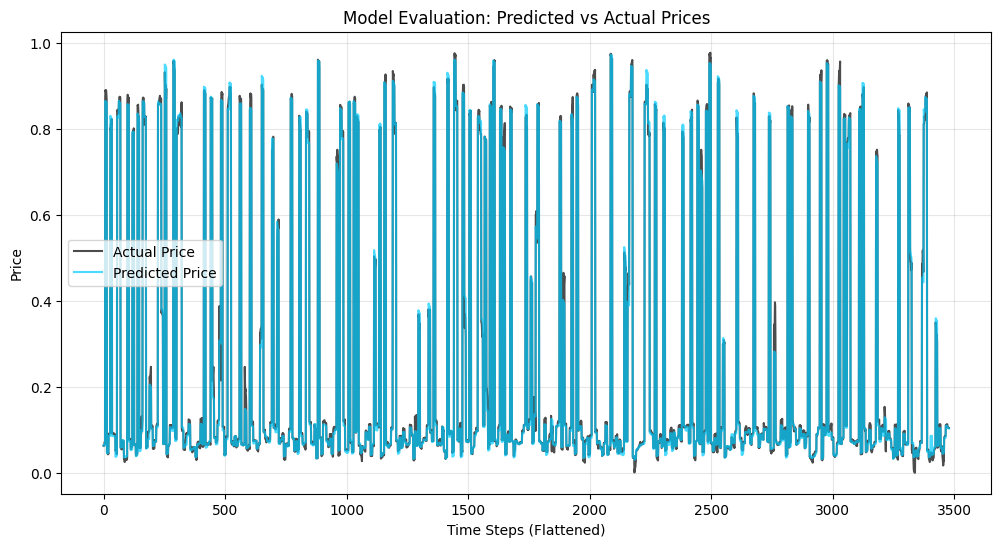

(0.008250512182712555, 0.9980528354644775, 0.5236106649534211)

In [16]:
evaluate_model(model=model_bi, val_loader=val_loader_basic , device= device)


In [17]:
def add_technical_indicators(df):
    df = df.copy()

    # 1. Simple Moving Averages (Trend)
    df['SMA_7'] = df['Close'].rolling(window=7).mean()
    df['SMA_25'] = df['Close'].rolling(window=25).mean()

    # 2. RSI (Momentum)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 3. MACD (Momentum)
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 4. Bollinger Bands (Volatility)
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['20dSTD'] = df['Close'].rolling(window=20).std()
    df['Upper_Band'] = df['MA20'] + (df['20dSTD'] * 2)
    df['Lower_Band'] = df['MA20'] - (df['20dSTD'] * 2)

    return df

# Usage
df_engineered = add_technical_indicators(df)

In [18]:
FEATURE_COLS = ['Open', 'High', 'Low', 'Adj Close', 'Volume',
                'SMA_7', 'SMA_25', 'RSI', 'MACD', 'MA20',
                '20dSTD', 'Upper_Band', 'Lower_Band']

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
df_engineered[FEATURE_COLS] = feature_scaler.fit_transform(df_engineered[FEATURE_COLS])

df_engineered.dropna(inplace=True)

df_engineered['Close'] = target_scaler.fit_transform(df_engineered[['Close']])

def create_price_sequences(df, seq_length, forecast_length, feature_cols):
    sequences = []
    
    data_features = df[feature_cols].values
    data_close = df['Close'].values

    for i in range(len(df) - seq_length - forecast_length):
        seq = data_features[i : i + seq_length]
        
        price_target = data_close[i + seq_length : i + seq_length + forecast_length]

        sequences.append((seq, price_target))
        
    return sequences

SEQ_LENGTH = 60
FORECAST_LENGTH = 7

sequences = create_price_sequences(df_engineered, SEQ_LENGTH, FORECAST_LENGTH, FEATURE_COLS)

X_list, y_price_list = zip(*sequences)

X = np.array(X_list)
y_price = np.array(y_price_list)

X_train, X_val, yp_train, yp_val = train_test_split(
    X, y_price, test_size=0.1, shuffle=False,random_state=42
)

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(yp_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(yp_val, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [19]:
class AdvancedCLAM_PriceOnly(nn.Module):
    def __init__(self, input_dim, seq_length=60, hidden_dim=256, num_heads=4, forecast_length=7):
        super(AdvancedCLAM_PriceOnly, self).__init__()
        
        self.seq_length = seq_length
        self.hidden_dim = hidden_dim 

        self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1) 
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1) 
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.dropout2 = nn.Dropout(0.3)
        self.conv3 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1) 
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.dropout3 = nn.Dropout(0.3)

        self.lstm1 = nn.LSTM(input_size=hidden_dim, hidden_size=hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.lstm2 = nn.LSTM(input_size=hidden_dim * 2, hidden_size=hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        self.lstm3 = nn.LSTM(input_size=hidden_dim * 2, hidden_size=hidden_dim, num_layers=2, batch_first=True, bidirectional=True, dropout=0.3)
        
        self.attention = nn.MultiheadAttention(embed_dim=hidden_dim*2, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim*2)

        self.price_head = nn.Sequential(
            nn.Linear(hidden_dim*2, 64),
            nn.ReLU(),
            nn.Linear(64, forecast_length)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.dropout1(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout2(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout3(F.relu(self.bn3(self.conv3(x)))) 

        x = x.permute(0, 2, 1)

        x, _ = self.lstm1(x) 
        x, _ = self.lstm2(x)
        lstm_out, _ = self.lstm3(x) 

        attn_output, _ = self.attention(lstm_out, lstm_out, lstm_out)
        x = self.norm(lstm_out + attn_output)

        context_vector = torch.mean(x, dim=1)

        price_pred = self.price_head(context_vector)

        return price_pred

In [20]:
"""from tqdm import tqdm
import torch

def train_both(model, train_loader, epoch, optimizer, criterion_price, criterion_trend, lambda_price, lambda_trend):
    model.train()
    total_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for inputs, targets_price, targets_trend in loop:
        inputs = inputs.to(device)
        targets_price = targets_price.to(device)
        targets_trend = targets_trend.to(device)

        pred_price, pred_trend = model(inputs)

        loss_price = criterion_price(pred_price, targets_price)
        loss_trend = criterion_trend(pred_trend, targets_trend)

        loss = (lambda_price * loss_price) + (lambda_trend * loss_trend)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        loop.set_postfix(price_loss=loss_price.item(), trend_loss=loss_trend.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}: Train Loss: {avg_loss:.6f}")
    return avg_loss

def test_both(model, val_loader, epoch, criterion_price, criterion_trend, lambda_price, lambda_trend):
    model.eval()
    val_total_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets_price, targets_trend in val_loader:
            inputs = inputs.to(device)
            targets_price = targets_price.to(device)
            targets_trend = targets_trend.to(device)

            pred_price, pred_trend = model(inputs)
            
            loss_price = criterion_price(pred_price, targets_price)
            loss_trend = criterion_trend(pred_trend, targets_trend)
            
            loss = (lambda_price * loss_price) + (lambda_trend * loss_trend)
            val_total_loss += loss.item()

    avg_val_loss = val_total_loss / len(val_loader)
    print(f"Epoch {epoch+1}: Val Loss: {avg_val_loss:.6f}")
    return avg_val_loss"""

'from tqdm import tqdm\nimport torch\n\ndef train_both(model, train_loader, epoch, optimizer, criterion_price, criterion_trend, lambda_price, lambda_trend):\n    model.train()\n    total_loss = 0.0\n\n    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")\n\n    for inputs, targets_price, targets_trend in loop:\n        inputs = inputs.to(device)\n        targets_price = targets_price.to(device)\n        targets_trend = targets_trend.to(device)\n\n        pred_price, pred_trend = model(inputs)\n\n        loss_price = criterion_price(pred_price, targets_price)\n        loss_trend = criterion_trend(pred_trend, targets_trend)\n\n        loss = (lambda_price * loss_price) + (lambda_trend * loss_trend)\n\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n        total_loss += loss.item()\n\n        loop.set_postfix(price_loss=loss_price.item(), trend_loss=loss_trend.item())\n\n    avg_loss = total_loss / len(train_loader)\n    print(f"Epoch {epoch+1}: Train

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedCLAM_PriceOnly(input_dim=len(FEATURE_COLS), seq_length=SEQ_LENGTH).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def train_price_only(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    loop = tqdm(loader, leave=False) 

    for inputs, targets in loop:
        inputs = inputs.to(device)
        targets = targets.to(device)

        preds = model(inputs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

def validate_price_only(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            preds = model(inputs)
            loss = criterion(preds, targets)
            total_loss += loss.item()

    return total_loss / len(loader)

num_epochs = 100
patience = 10
patience_counter = 0
best_val_loss = float('inf')
history_adv = []
print("Starting Training (Price Only)...")

for epoch in range(num_epochs):
    train_loss = train_price_only(model, train_loader, optimizer, criterion)
    val_loss = validate_price_only(model, val_loader, criterion)
    
    scheduler.step(val_loss)
    history_adv.append([avg_train_loss,avg_val_loss])
    
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "AdvancedCLAM_PriceOnly.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Starting Training (Price Only)...


Epoch 1: Train Loss: 0.012419 | Val Loss: 0.000574


Epoch 2: Train Loss: 0.001519 | Val Loss: 0.000231


Epoch 3: Train Loss: 0.001349 | Val Loss: 0.000094


Epoch 4: Train Loss: 0.001017 | Val Loss: 0.000179


...

Epoch 17: Train Loss: 0.000395 | Val Loss: 0.000119


Epoch 18: Train Loss: 0.000356 | Val Loss: 0.000235


Epoch 19: Train Loss: 0.000344 | Val Loss: 0.000168


Epoch 20: Train Loss: 0.000295 | Val Loss: 0.000187


Epoch 21: Train Loss: 0.000348 | Val Loss: 0.000079
Early stopping triggered.


In [22]:
model_adv = AdvancedCLAM_PriceOnly(input_dim=len(FEATURE_COLS), seq_length=SEQ_LENGTH).to(device)

In [23]:
model_adv = load_model("AdvancedCLAM_PriceOnly.pth",device,model_adv)

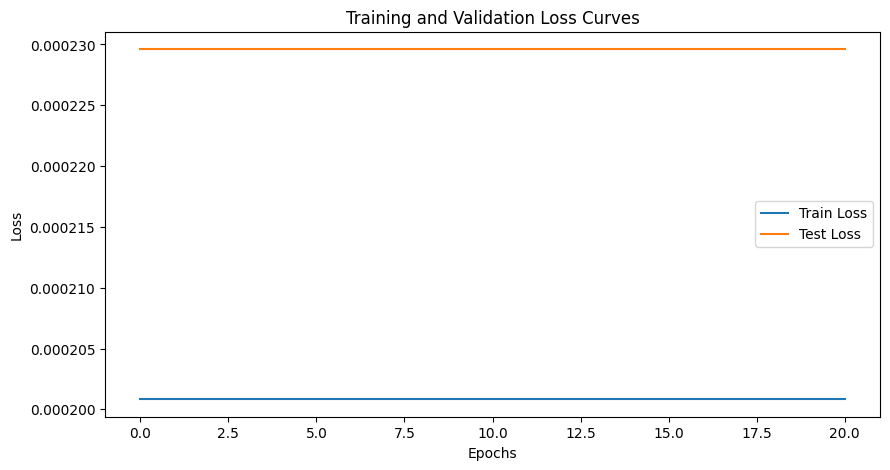

In [31]:
plot_training_curves(history_adv)



   PRICE PREDICTION METRICS (Regression)
Mean Absolute Error (MAE): 0.004853
Root Mean Squared Error (RMSE): 0.006009
R-Squared (R2): 0.745646

   DERIVED TREND METRICS (Classification)
Directional F1 Score: 0.5271
Directional Accuracy: 51.98%


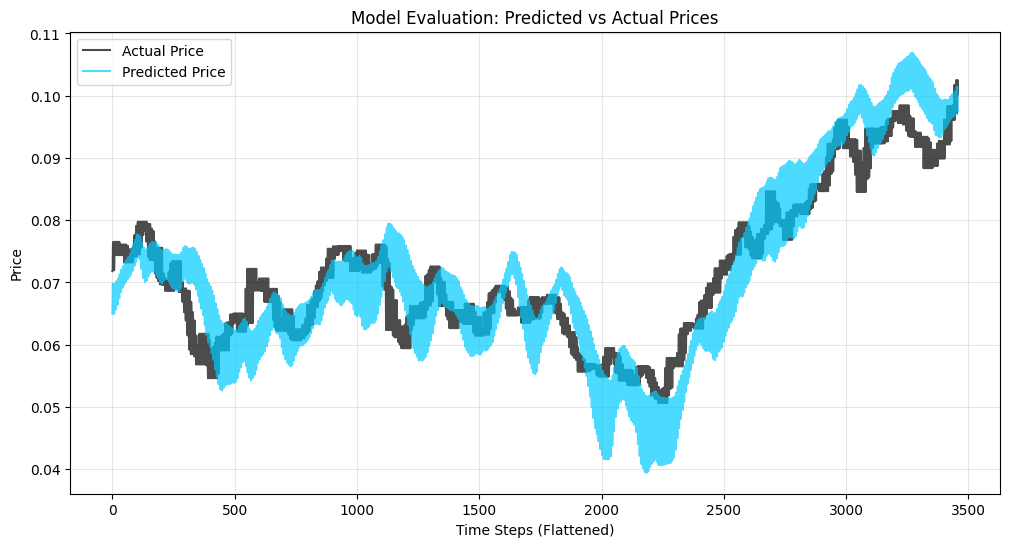

(0.004853026941418648, 0.7456458806991577, 0.5270655270655271)

In [24]:
evaluate_model(model=model_adv, val_loader=val_loader , device= device)

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

class AttLayer(nn.Module):
    def __init__(self, hidden_size, seq_len):
        super(AttLayer, self).__init__()
        self.W = nn.Linear(hidden_size, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(seq_len, 1))
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        e = torch.tanh(self.W(x) + self.bias)
        e = e.squeeze(-1)
        alpha = self.softmax(e)
        alpha = alpha.unsqueeze(-1)
        output = torch.sum(alpha * x, dim=1)
        return output

class BabaModel_skip(nn.Module):
    def __init__(self, input_dim=13, k_size=3, seq_len=60): 
        super(BabaModel_skip, self).__init__()
        
        # Updated to use input_dim instead of hardcoded 13
        self.conv1 = nn.Conv1d(input_dim, 128, kernel_size=k_size, padding=1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=k_size, padding=1)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.conv3 = nn.Conv1d(128, 128, kernel_size=k_size, padding=1)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        
        self.lstm = nn.LSTM(128, 200, batch_first=True)
        self.dropout4 = nn.Dropout(0.3)
        
        self.lstm2 = nn.LSTM(200 + 128, 200, batch_first=True)
        self.dropout5 = nn.Dropout(0.3)
        
        self.lstm3 = nn.LSTM(200 + 128 + 128, 200, batch_first=True)
        self.dropout6 = nn.Dropout(0.3)
        
        self.att = AttLayer(200, seq_len=seq_len)
        self.fc = nn.Linear(200, 7)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # --- FIX IS HERE ---
        # Input x shape: [Batch, Seq_Len, Features] -> e.g. [64, 60, 13]
        # Conv1d expects: [Batch, Features, Seq_Len]
        x = x.permute(0, 2, 1) 
        
        # Now x is [64, 13, 60], which matches conv1 input channels (13)
        x = self.conv1(x)
        x = self.relu1(x)
        x1 = x  # Save for skip connection (Shape: Batch, 128, Seq)
        
        x = self.dropout1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x2 = x  # Save for skip connection (Shape: Batch, 128, Seq)
        
        x = self.dropout2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        
        # Permute back for LSTM: [Batch, Channels, Seq] -> [Batch, Seq, Channels]
        x = x.permute(0, 2, 1) 
        
        x, _ = self.lstm(x)
        x = self.dropout4(x)
        
        # Skip connections need permutation too: (Batch, 128, Seq) -> (Batch, Seq, 128)
        x, _ = self.lstm2(torch.cat((x, x1.permute(0, 2, 1)), dim=2))
        x = self.dropout5(x)
        
        x, _ = self.lstm3(torch.cat((x, x1.permute(0, 2, 1), x2.permute(0, 2, 1)), dim=2))
        x = self.dropout6(x)
        
        x = self.att(x)
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

# --- Usage ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTUAL_SEQ_LENGTH = 60
INPUT_FEATURES = 13  # Make sure this matches your data (based on your error it is 13)

# Initialize with correct input dim and sequence length
model_skip = BabaModel_skip(input_dim=INPUT_FEATURES, k_size=3, seq_len=ACTUAL_SEQ_LENGTH).to(device)

optimizer = optim.Adam(model_skip.parameters(), lr=0.001)
MSE = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5)

# (Then run your training loop as before)

In [26]:
patience = 10
patience_counter = 0
best_val_loss = float('inf')
num_epochs = 100
history_skip = []
for epoch in range(num_epochs):
    avg_train_loss = train_one_epoch(model=model_skip,train_loader=train_loader,epoch=epoch,optimizer=optimizer)
    avg_val_loss = validate(model=model_skip,val_loader=val_loader)

    schedular.step(avg_val_loss)
    history_skip.append([avg_train_loss,avg_val_loss])
    
    if avg_val_loss < best_val_loss:
        torch.save(model_skip.state_dict(), "model_skip.pth")

        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"EarlyStopping counter: {patience_counter} out of {patience}")
        if patience_counter >= patience:
            print("Early stopping triggered. Training halted.")
            break



Epoch 1/100 [Train]: 100%|██████████| 70/70 [00:01<00:00, 53.62it/s, loss=0.00177]


Epoch 1: Train Loss: 0.021923


100%|██████████| 8/8 [00:00<00:00, 74.31it/s, loss=4.9e-5]


Val Loss: 0.000838


Epoch 2/100 [Train]: 100%|██████████| 70/70 [00:01<00:00, 46.53it/s, loss=0.00113] 


...

Val Loss: 0.000057
EarlyStopping counter: 9 out of 10


Epoch 16/100 [Train]: 100%|██████████| 70/70 [00:01<00:00, 56.89it/s, loss=0.00043] 


Epoch 16: Train Loss: 0.000326


100%|██████████| 8/8 [00:00<00:00, 129.90it/s, loss=0.000259]

Val Loss: 0.000129
EarlyStopping counter: 10 out of 10
Early stopping triggered. Training halted.


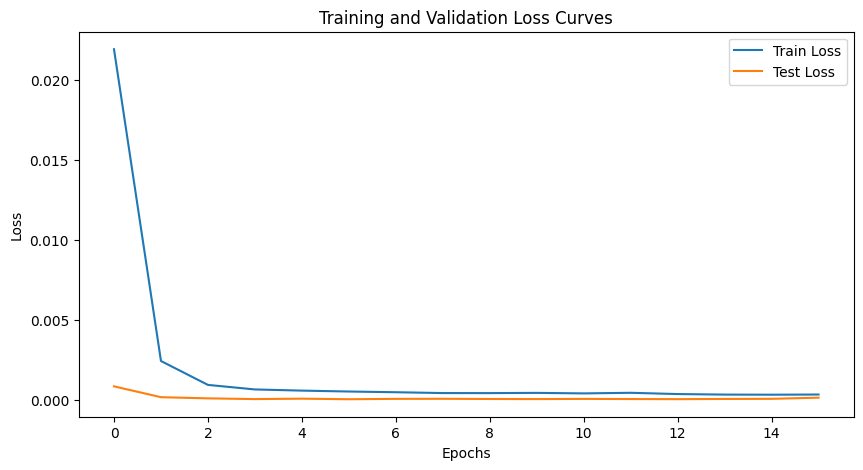

In [32]:
plot_training_curves(history_skip)



   PRICE PREDICTION METRICS (Regression)
Mean Absolute Error (MAE): 0.009442
Root Mean Squared Error (RMSE): 0.011130
R-Squared (R2): 0.127416

   DERIVED TREND METRICS (Classification)
Directional F1 Score: 0.6689
Directional Accuracy: 52.33%


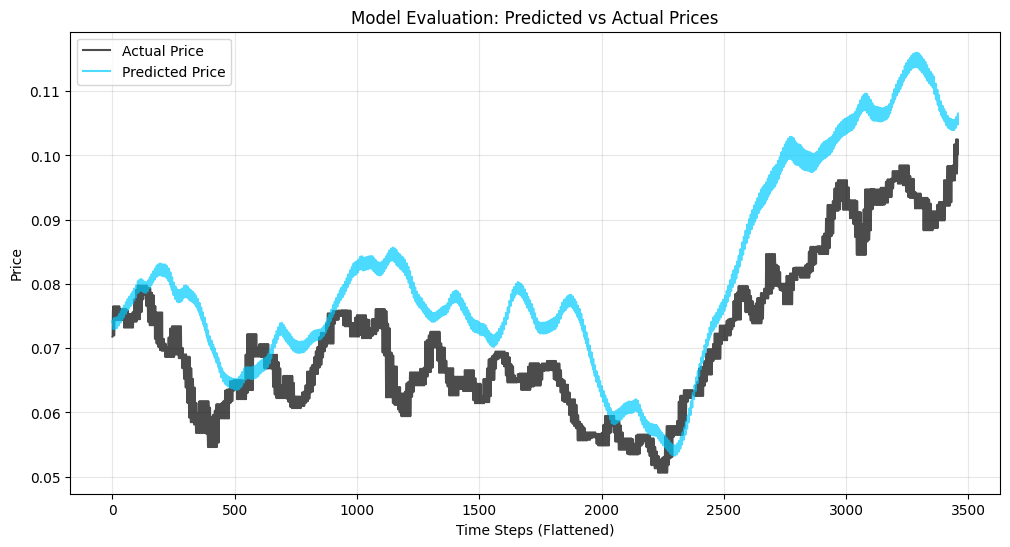

(0.009442423470318317, 0.12741577625274658, 0.6689433507432704)

In [27]:
evaluate_model(model_skip,val_loader,device)

In [37]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=BabaModel(input_dim=13,k_size=3,seq_len=60).to(device)
MSE=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
schedular=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",factor=0.1,patience=5)

patience = 10
patience_counter = 0
best_val_loss = float('inf')
num_epochs = 1000
history_base_rsi = []
for epoch in range(num_epochs):
    avg_train_loss = train_one_epoch(model=model,train_loader=train_loader,epoch=epoch,optimizer=optimizer)
    avg_val_loss = validate(model=model,val_loader=val_loader)

    schedular.step(avg_val_loss)
    history_base.append([avg_train_loss,avg_val_loss])
    if avg_val_loss < best_val_loss:
        torch.save(model.state_dict(), "Baba_model_rsi.pth")

        best_val_loss = avg_val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"EarlyStopping counter: {patience_counter} out of {patience}")
        if patience_counter >= patience:
            print("Early stopping triggered. Training halted.")
            break



Epoch 1/1000 [Train]: 100%|██████████| 70/70 [00:01<00:00, 56.49it/s, loss=0.00125] 


Epoch 1: Train Loss: 0.014961


100%|██████████| 8/8 [00:00<00:00, 179.41it/s, loss=0.000298]


Val Loss: 0.000180


Epoch 2/1000 [Train]: 100%|██████████| 70/70 [00:01<00:00, 69.01it/s, loss=0.00137] 


...

Val Loss: 0.000019
EarlyStopping counter: 9 out of 10


Epoch 53/1000 [Train]: 100%|██████████| 70/70 [00:01<00:00, 61.63it/s, loss=0.000292]


Epoch 53: Train Loss: 0.000309


100%|██████████| 8/8 [00:00<00:00, 174.88it/s, loss=2.3e-5]

Val Loss: 0.000019
EarlyStopping counter: 10 out of 10
Early stopping triggered. Training halted.


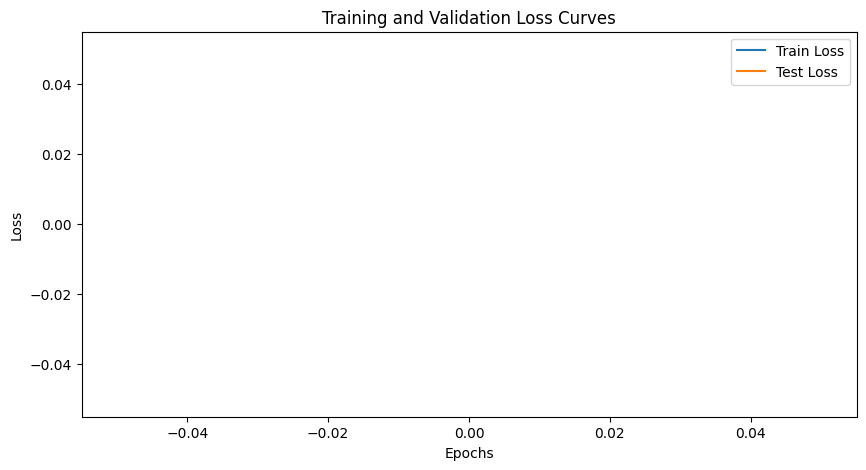

In [38]:
plot_training_curves(history_base_rsi)



   PRICE PREDICTION METRICS (Regression)
Mean Absolute Error (MAE): 0.003417
Root Mean Squared Error (RMSE): 0.004393
R-Squared (R2): 0.864070

   DERIVED TREND METRICS (Classification)
Directional F1 Score: 0.6120
Directional Accuracy: 54.44%


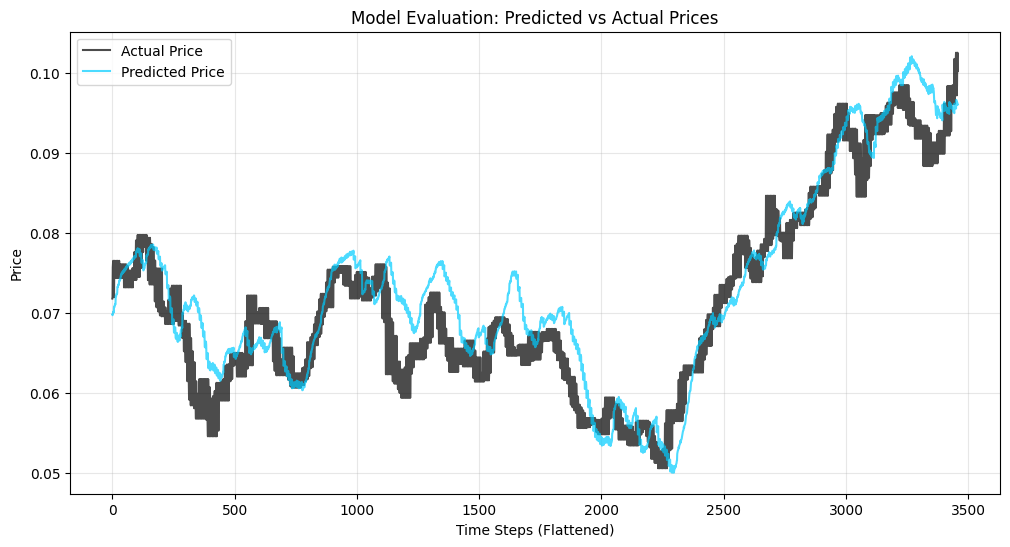

(0.0034171210136264563, 0.8640697598457336, 0.6119733924611973)

In [39]:
evaluate_model(model,val_loader,device)
